# ---------- Stationary distribution analysis notebook - eigenproblem ----------

The goal of this notebook is to compute the stationary distribution of the London bike-sharing station network built in the previous notebook.

The main method used here is the eigenproblem for the transition matrix. The power method is kept as a reference result for comparison.

Author: Artur Werys

In [1]:
from pathlib import Path

import math

import pandas as pd
import numpy as np

import networkx as nx

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

import geopandas as gpd
import contextily as ctx


/Users/artur/Studia/Rowerki/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
def find_project_root(start=None):
    current = Path.cwd() if start is None else Path(start)
    for path in [current, *current.parents]:
        if (path / "Data").exists():
            return path
    raise FileNotFoundError("Could not find project root containing Data/")


PROJECT_ROOT = find_project_root()
BASE_DIR = PROJECT_ROOT
DATA_DIR = PROJECT_ROOT / "Data"
PAIR_ROAD_DISTANCES_FILE = DATA_DIR / "station_pair_road_distances.parquet"

SCALE_TICK_INTERVAL_KM = 0.5


def mercator_latitude_from_y(y):

    web_mercator_radius_m = 6_378_137

    return math.degrees(
        2 * math.atan(math.exp(y / web_mercator_radius_m)) - math.pi / 2
    )


def web_mercator_width_for_ground_distance(ax, distance_km):

    y_min, y_max = ax.get_ylim()
    center_lat = mercator_latitude_from_y((y_min + y_max) / 2)
    latitude_scale = max(math.cos(math.radians(center_lat)), 0.1)

    return distance_km * 1000 / latitude_scale


def format_scale_distance_label(distance_km, include_unit=False):

    if include_unit:
        return f"{distance_km:.2f} km"

    rounded_distance = round(distance_km, 1)

    if math.isclose(rounded_distance, round(rounded_distance), abs_tol=0.01):
        return f"{round(rounded_distance):.0f}"

    return f"{rounded_distance:.1f}"


def scale_tick_marks(distance_km, tick_interval_km=SCALE_TICK_INTERVAL_KM):

    if distance_km <= 0:
        return [(0.0, 0.0)]

    marks = []
    tick_count = int(math.floor(distance_km / tick_interval_km))

    for tick_index in range(tick_count + 1):
        tick_distance_km = tick_index * tick_interval_km
        marks.append((tick_distance_km / distance_km, tick_distance_km))

    if not math.isclose(marks[-1][0], 1.0):
        marks.append((1.0, distance_km))

    return marks


def add_average_route_scale_bar(ax, average_route_km, label="Średnia trasa"):

    if average_route_km is None or not np.isfinite(average_route_km) or average_route_km <= 0:
        return

    x_min, x_max = ax.get_xlim()
    map_width = x_max - x_min

    bar_width_axes = web_mercator_width_for_ground_distance(
        ax,
        average_route_km
    ) / map_width

    if bar_width_axes > 0.42:
        return

    panel_width_axes = max(bar_width_axes + 0.035, 0.22)
    panel_height_axes = 0.073

    scale_ax = ax.inset_axes(
        [0.028, 0.050, panel_width_axes, panel_height_axes],
        zorder=30
    )
    scale_ax.set_axis_off()
    scale_ax.set_xlim(0, 1)
    scale_ax.set_ylim(0, 1)

    panel = FancyBboxPatch(
        (0, 0),
        1,
        1,
        transform=scale_ax.transAxes,
        boxstyle="round,pad=0.010,rounding_size=0.035",
        facecolor="white",
        edgecolor="#B4BCC2",
        linewidth=0.8,
        alpha=0.86,
        clip_on=False,
        zorder=0
    )
    scale_ax.add_patch(panel)

    bar_fraction = bar_width_axes / panel_width_axes
    bar_x = (1 - bar_fraction) / 2
    bar_y = 0.39
    bar_color = "#232A32"

    scale_ax.text(
        0.5,
        0.73,
        f"{label}: {average_route_km:.2f} km",
        ha="center",
        va="center",
        fontsize=8,
        fontweight="bold",
        color=bar_color,
        transform=scale_ax.transAxes,
        zorder=2
    )

    scale_ax.plot(
        [bar_x, bar_x + bar_fraction],
        [bar_y, bar_y],
        color=bar_color,
        linewidth=1.6,
        transform=scale_ax.transAxes,
        zorder=2
    )

    selected_labels = []
    min_label_gap = 0.11
    tick_marks = scale_tick_marks(average_route_km)

    for tick_index, (tick_fraction, tick_distance_km) in enumerate(tick_marks):

        tick_x = bar_x + bar_fraction * tick_fraction

        scale_ax.plot(
            [tick_x, tick_x],
            [bar_y - 0.09, bar_y + 0.09],
            color=bar_color,
            linewidth=0.9,
            transform=scale_ax.transAxes,
            zorder=2
        )

        is_final_tick = tick_index == len(tick_marks) - 1
        label_text = format_scale_distance_label(
            tick_distance_km,
            include_unit=is_final_tick
        )

        if is_final_tick:
            while selected_labels and tick_x - selected_labels[-1][0] < min_label_gap:
                selected_labels.pop()
            selected_labels.append((tick_x, label_text))

        elif not selected_labels or tick_x - selected_labels[-1][0] >= min_label_gap:
            selected_labels.append((tick_x, label_text))

    for label_x, label_text in selected_labels:

        scale_ax.text(
            label_x,
            0.14,
            label_text,
            ha="center",
            va="center",
            fontsize=7,
            color=bar_color,
            transform=scale_ax.transAxes,
            zorder=2
        )

padding = 2800

In [3]:
edges_df = pd.read_parquet(DATA_DIR / "edges_df.parquet")
stations_df = pd.read_parquet(DATA_DIR / "stations_df.parquet")
station_pair_road_distances = pd.read_parquet(PAIR_ROAD_DISTANCES_FILE)

non_loop_edges_df = edges_df[
    edges_df["start_station_name"] != edges_df["end_station_name"]
].copy()

all_route_lengths = non_loop_edges_df.merge(
    station_pair_road_distances[
        ["start_station_name", "end_station_name", "road_distance_km"]
    ],
    on=["start_station_name", "end_station_name"],
    how="inner"
)

average_route_km = np.average(
    all_route_lengths["road_distance_km"],
    weights=all_route_lengths["weight"]
)

covered_trip_count = int(all_route_lengths["weight"].sum())
expected_trip_count = int(non_loop_edges_df["weight"].sum())

average_route_length_summary = pd.DataFrame([
    {
        "typ_danych": "Wszystkie przejazdy (2 lata)",
        "srednia_dlugosc_trasy_km": average_route_km,
        "liczba_przejazdow_z_odlegloscia": covered_trip_count,
        "pokrycie_przejazdow_%": covered_trip_count / expected_trip_count * 100 if expected_trip_count else np.nan,
    }
])

display(edges_df.head())
display(average_route_length_summary.round(2))

,start_station_id,start_station_name,end_station_id,end_station_name,weight
0,959,"Milroy Walk, South Bank",959.0,"Milroy Walk, South Bank",296
1,959,"Milroy Walk, South Bank",960.0,"Hop Exchange, The Borough",622
2,959,"Milroy Walk, South Bank",961.0,"Union Street, The Borough",159
3,959,"Milroy Walk, South Bank",962.0,"Stamford Street, South Bank",221
4,959,"Milroy Walk, South Bank",963.0,"Bankside Mix, Bankside",231


,typ_danych,srednia_dlugosc_trasy_km,liczba_przejazdow_z_odlegloscia,pokrycie_przejazdow_%
0,Wszystkie przejazdy (2 lata),2.95,16806011,100.0


In [4]:
stations_df.head()

,station_id,station_name,lat,lon
0,1108.0,"North Wharf Road, Paddington",51.518623,-0.176603
1,3447.0,"Gloucester Road (North), Kensington",51.497925,-0.183835
2,1090.0,"Warren Street Station, Euston",51.524438,-0.138019
3,200058.0,"Northdown Street, King's Cross",51.531066,-0.119340
4,1052.0,"Soho Square , Soho",51.515631,-0.132329


In [5]:
graph = nx.from_pandas_edgelist(
    edges_df,
    source="start_station_name",
    target="end_station_name",
    edge_attr="weight",
    create_using=nx.DiGraph()
)

## Create a dictionary to store station names and their geographic coordinates (longitude and latitude)

In [6]:
# positions = {
#    "Waterloo Station": (-0.113, 51.503),
#    "Hyde Park Corner": (-0.152, 51.502),
#    ...
#}

positions = {}

for _, row in stations_df.iterrows():

    positions[row["station_name"]] = (
        row["lon"],
        row["lat"]
    )

## Create a mapping from station IDs to matrix indices

In [7]:
station_to_index = {
    station_id: idx
    for idx, station_id in enumerate(
        sorted(stations_df["station_id"].unique())
    )
}

print(station_to_index)

{np.float64(959.0): 0, np.float64(960.0): 1, np.float64(961.0): 2, np.float64(962.0): 3, np.float64(963.0): 4, np.float64(964.0): 5, np.float64(965.0): 6, np.float64(966.0): 7, np.float64(967.0): 8, np.float64(968.0): 9, np.float64(969.0): 10, np.float64(970.0): 11, np.float64(971.0): 12, np.float64(972.0): 13, np.float64(973.0): 14, np.float64(974.0): 15, np.float64(975.0): 16, np.float64(976.0): 17, np.float64(978.0): 18, np.float64(979.0): 19, np.float64(980.0): 20, np.float64(981.0): 21, np.float64(982.0): 22, np.float64(983.0): 23, np.float64(984.0): 24, np.float64(985.0): 25, np.float64(986.0): 26, np.float64(988.0): 27, np.float64(989.0): 28, np.float64(990.0): 29, np.float64(991.0): 30, np.float64(992.0): 31, np.float64(993.0): 32, np.float64(994.0): 33, np.float64(995.0): 34, np.float64(996.0): 35, np.float64(997.0): 36, np.float64(998.0): 37, np.float64(999.0): 38, np.float64(1000.0): 39, np.float64(1001.0): 40, np.float64(1002.0): 41, np.float64(1003.0): 42, np.float64(1004.

In [8]:
index_to_station = {
    idx: station_id
    for station_id, idx in station_to_index.items()
}

print(index_to_station)

{0: np.float64(959.0), 1: np.float64(960.0), 2: np.float64(961.0), 3: np.float64(962.0), 4: np.float64(963.0), 5: np.float64(964.0), 6: np.float64(965.0), 7: np.float64(966.0), 8: np.float64(967.0), 9: np.float64(968.0), 10: np.float64(969.0), 11: np.float64(970.0), 12: np.float64(971.0), 13: np.float64(972.0), 14: np.float64(973.0), 15: np.float64(974.0), 16: np.float64(975.0), 17: np.float64(976.0), 18: np.float64(978.0), 19: np.float64(979.0), 20: np.float64(980.0), 21: np.float64(981.0), 22: np.float64(982.0), 23: np.float64(983.0), 24: np.float64(984.0), 25: np.float64(985.0), 26: np.float64(986.0), 27: np.float64(988.0), 28: np.float64(989.0), 29: np.float64(990.0), 30: np.float64(991.0), 31: np.float64(992.0), 32: np.float64(993.0), 33: np.float64(994.0), 34: np.float64(995.0), 35: np.float64(996.0), 36: np.float64(997.0), 37: np.float64(998.0), 38: np.float64(999.0), 39: np.float64(1000.0), 40: np.float64(1001.0), 41: np.float64(1002.0), 42: np.float64(1003.0), 43: np.float64(1

## Stationary distribution calculation

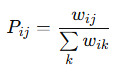

### Construction of the weight matrix

The element `w_ij` stores the number of trips from station `i` to station `j`.

$$
W = [w_{ij}]
$$

In [9]:
N = len(stations_df["station_id"].unique())

wij_matrix = np.zeros((N, N))


for _, row in edges_df.iterrows():

        start_station = row["start_station_id"]
        end_station = row["end_station_id"]
        weight = row["weight"]

        i = station_to_index[start_station]
        j = station_to_index[end_station]


        wij_matrix[i][j] = weight

wij_matrix.shape

(801, 801)

### Total outgoing traffic from each station

For each station `i`, all outgoing trips are summed over all possible destination stations.

$$
w_{i \cdot} = \sum_{k=1}^{N} w_{ik}
$$

In [10]:
wik_sum = wij_matrix.sum(axis=1)
wik_sum.shape

(801,)

### Reshape wik_sum to be a column vector instead of a 1D array to perform matrix division correctly


In [11]:
wik_sum = wik_sum.reshape((-1, 1))
wik_sum.shape

(801, 1)

### Finally Pij matrix

The transition probability from station `i` to station `j` is computed by normalizing the row of the weight matrix.

$$
p_{ij} = \frac{w_{ij}}{\sum_{k=1}^{N} w_{ik}}
$$

In [12]:
Pij_matrix = wij_matrix / wik_sum

print(Pij_matrix)

[[0.01525695 0.0320602  0.00819545 ... 0.00113396 0.00762847 0.00257719]
 [0.00712542 0.02028331 0.00475501 ... 0.00265429 0.00547891 0.00202975]
 [0.005588   0.02038864 0.0233085  ... 0.00045308 0.00463149 0.00372533]
 ...
 [0.00170948 0.00859122 0.00048216 ... 0.0216972  0.00219164 0.00105199]
 [0.00186766 0.02114461 0.00296825 ... 0.00243463 0.06723586 0.01784285]
 [0.00248139 0.0083871  0.00431762 ... 0.00143921 0.02024814 0.03473945]]


### Since Pij_matrix is a transition probability matrix, each row should sum to 1

$$
\sum_{j=1}^{N} p_{ij} = 1
$$

In [13]:
Pij_matrix.sum(axis=1)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1.

### Stationary distribution computation using the power method

This part is kept as a reference result, because it allows to compare the iterative result with the eigenproblem result.

At the beginning, all stations are assigned the same probability equal to `1/N`.

$$
p_i^{(0)} = \frac{1}{N}
$$

In each iteration the probability vector is multiplied by the transition matrix.

$$
p^{(t+1)} = p^{(t)}P
$$

In [14]:
p_t0_matrix = np.zeros((1, N))
p_t0_matrix[0, :] = 1/N
print(p_t0_matrix)

[[0.00124844 0.00124844 0.00124844 0.00124844 0.00124844 0.00124844
  0.00124844 0.00124844 0.00124844 0.00124844 0.00124844 0.00124844
  0.00124844 0.00124844 0.00124844 0.00124844 0.00124844 0.00124844
  0.00124844 0.00124844 0.00124844 0.00124844 0.00124844 0.00124844
  0.00124844 0.00124844 0.00124844 0.00124844 0.00124844 0.00124844
  0.00124844 0.00124844 0.00124844 0.00124844 0.00124844 0.00124844
  0.00124844 0.00124844 0.00124844 0.00124844 0.00124844 0.00124844
  0.00124844 0.00124844 0.00124844 0.00124844 0.00124844 0.00124844
  0.00124844 0.00124844 0.00124844 0.00124844 0.00124844 0.00124844
  0.00124844 0.00124844 0.00124844 0.00124844 0.00124844 0.00124844
  0.00124844 0.00124844 0.00124844 0.00124844 0.00124844 0.00124844
  0.00124844 0.00124844 0.00124844 0.00124844 0.00124844 0.00124844
  0.00124844 0.00124844 0.00124844 0.00124844 0.00124844 0.00124844
  0.00124844 0.00124844 0.00124844 0.00124844 0.00124844 0.00124844
  0.00124844 0.00124844 0.00124844 0.00124844 0.

### Power method iterations

In [15]:
p_t1_matrix = np.zeros((1, N))

diff = abs(p_t1_matrix - p_t0_matrix). sum()
iteration = 0

while diff > 1e-10:
    p_t1_matrix = p_t0_matrix @ Pij_matrix
    diff = abs(p_t1_matrix - p_t0_matrix). sum()
    p_t0_matrix = p_t1_matrix
    iteration += 1

print(iteration)

stationary_distribution_power = p_t1_matrix


78


/var/folders/8p/j63xl3c17439n25jbp9cyjg40000gn/T/ipykernel_15453/538208905.py:7: RuntimeWarning: divide by zero encountered in matmul
  p_t1_matrix = p_t0_matrix @ Pij_matrix
/var/folders/8p/j63xl3c17439n25jbp9cyjg40000gn/T/ipykernel_15453/538208905.py:7: RuntimeWarning: overflow encountered in matmul
  p_t1_matrix = p_t0_matrix @ Pij_matrix
/var/folders/8p/j63xl3c17439n25jbp9cyjg40000gn/T/ipykernel_15453/538208905.py:7: RuntimeWarning: invalid value encountered in matmul
  p_t1_matrix = p_t0_matrix @ Pij_matrix


### The stationary distribution from the power method should sum to 1

In [16]:
print(stationary_distribution_power.sum().round(5))

1.0


In [17]:
print(stationary_distribution_power)

[[1.19694307e-03 5.20180163e-03 1.19495217e-03 1.34156917e-03
  1.67731024e-03 1.74637100e-03 1.33896265e-03 1.25083590e-03
  1.16555550e-03 2.44765210e-03 1.18462916e-03 1.01269414e-03
  1.62957351e-03 1.77936267e-03 2.85803667e-03 1.79672063e-03
  1.34723658e-03 7.30692565e-04 1.57601533e-03 1.29073356e-03
  2.43259706e-03 1.71921551e-03 3.24075180e-03 7.56090953e-04
  3.17781444e-03 1.52455422e-03 7.37198256e-04 1.38516439e-03
  9.42258326e-04 7.97599133e-04 3.00247633e-03 6.67856204e-04
  6.71858033e-04 1.65152870e-03 3.27034337e-03 1.24705741e-03
  1.70114616e-03 1.36590774e-03 3.82978978e-03 2.39097427e-03
  8.55440066e-04 1.29155351e-03 1.38425055e-03 1.40728181e-03
  8.56707247e-04 9.14236672e-04 2.47295596e-03 1.79769457e-03
  1.43848336e-03 1.16354013e-03 4.17912381e-03 9.45743310e-04
  8.15039233e-04 9.61768417e-04 1.04957531e-03 1.60303114e-03
  1.53987441e-03 8.90764122e-04 1.51141748e-03 1.62451931e-03
  5.85529009e-04 8.92418322e-04 1.28886000e-03 9.04709259e-04
  1.2330

## Stationary distribution calculation using the eigenproblem

For a row-stochastic transition matrix the stationary distribution does not change after one step.

$$
\pi P = \pi
$$

This can be written as a left eigenvector problem. To use the standard form of the eigenproblem, the equation is transposed.

$$
P^T \pi^T = \pi^T
$$

So the stationary distribution is the eigenvector of `Pij_matrix.T` corresponding to the eigenvalue equal to `1`.

### Standard eigenproblem notation

$$
A v = \lambda v
$$

In this notebook:

$$
A = P^T
$$

$$
\lambda = 1
$$

$$
v = \pi^T
$$

In [18]:
eigenvalues, eigenvectors = np.linalg.eig(Pij_matrix.T)

eigenvalue_index = np.argmin(
    np.abs(eigenvalues - 1)
)

stationary_eigenvalue = eigenvalues[eigenvalue_index]
stationary_eigenvector = np.real(
    eigenvectors[:, eigenvalue_index]
)

print(stationary_eigenvalue)

(1.000000000000003+0j)


### Normalize the eigenvector

Eigenvectors are defined up to multiplication by a constant, so the selected vector has to be converted into a probability distribution.

$$
\pi_i = \frac{v_i}{\sum_{j=1}^{N} v_j}
$$

If the eigenvector is returned with the opposite sign, it is first multiplied by `-1`.

In [19]:
if stationary_eigenvector.sum() < 0:
    stationary_eigenvector = -stationary_eigenvector

stationary_distribution_eigen = (
    stationary_eigenvector / stationary_eigenvector.sum()
).reshape((1, N))

print(stationary_distribution_eigen.sum().round(5))

1.0


In [20]:
print(stationary_distribution_eigen)

[[1.19694307e-03 5.20180163e-03 1.19495217e-03 1.34156917e-03
  1.67731024e-03 1.74637100e-03 1.33896265e-03 1.25083590e-03
  1.16555550e-03 2.44765210e-03 1.18462916e-03 1.01269414e-03
  1.62957351e-03 1.77936267e-03 2.85803667e-03 1.79672063e-03
  1.34723658e-03 7.30692565e-04 1.57601533e-03 1.29073356e-03
  2.43259706e-03 1.71921551e-03 3.24075181e-03 7.56090953e-04
  3.17781444e-03 1.52455422e-03 7.37198256e-04 1.38516439e-03
  9.42258326e-04 7.97599133e-04 3.00247633e-03 6.67856204e-04
  6.71858033e-04 1.65152870e-03 3.27034337e-03 1.24705741e-03
  1.70114616e-03 1.36590774e-03 3.82978979e-03 2.39097427e-03
  8.55440066e-04 1.29155351e-03 1.38425055e-03 1.40728181e-03
  8.56707247e-04 9.14236672e-04 2.47295596e-03 1.79769457e-03
  1.43848336e-03 1.16354013e-03 4.17912381e-03 9.45743311e-04
  8.15039234e-04 9.61768417e-04 1.04957531e-03 1.60303114e-03
  1.53987441e-03 8.90764122e-04 1.51141748e-03 1.62451931e-03
  5.85529009e-04 8.92418322e-04 1.28886000e-03 9.04709259e-04
  1.2330

### Comparison with the power method

The two methods should give the same stationary distribution up to numerical precision.

$$
\Delta_i = |\pi_i^{(eigen)} - \pi_i^{(power)}|
$$

In [21]:
distribution_difference = np.abs(
    stationary_distribution_eigen - stationary_distribution_power
)

comparison_summary = pd.DataFrame([
    {
        "metoda": "zagadnienie wlasne",
        "suma_prawdopodobienstw": stationary_distribution_eigen.sum(),
        "najwieksza_roznica_wzgledem_iteracji": distribution_difference.max(),
        "suma_roznic_wzgledem_iteracji": distribution_difference.sum(),
    },
    {
        "metoda": "metoda potegowa",
        "suma_prawdopodobienstw": stationary_distribution_power.sum(),
        "najwieksza_roznica_wzgledem_iteracji": 0.0,
        "suma_roznic_wzgledem_iteracji": 0.0,
    }
])

display(comparison_summary)

,metoda,suma_prawdopodobienstw,najwieksza_roznica_wzgledem_iteracji,suma_roznic_wzgledem_iteracji
0,zagadnienie wlasne,1.0,3.103216e-12,3.509013e-10
1,metoda potegowa,1.0,0.000000e+00,0.000000e+00


### Final stationary distribution

Because the differences are extremely small, the eigenproblem result can be used as the final stationary distribution in the remaining part of the notebook.

In [22]:
stationary_distribution = stationary_distribution_eigen

### 10 most important stations according to the eigenproblem

In [23]:
sorted_indices = np.argsort(stationary_distribution[0])[::-1]
sorted_probs = stationary_distribution[0][sorted_indices]

top_10_stations = sorted_indices[:10]
top_10_probs = sorted_probs[:10]

top_10_station_rows = []

for rank, (idx, prob) in enumerate(
    zip(top_10_stations, top_10_probs),
    start=1
):

    station_id = index_to_station[idx]

    station_name = stations_df[
        stations_df["station_id"] == station_id
    ]["station_name"].values[0]

    top_10_station_rows.append(
        {
            "rank": rank,
            "station_id": station_id,
            "station_name": station_name,
            "p_eigenproblem": prob,
            "p_power_method": stationary_distribution_power[0][idx],
            "absolute_difference": abs(
                prob - stationary_distribution_power[0][idx]
            )
        }
    )

top_10_stations_df = pd.DataFrame(top_10_station_rows)

display(top_10_stations_df)

,rank,station_id,station_name,p_eigenproblem,p_power_method,absolute_difference
0,1,1072.0,"Waterloo Station 3, Waterloo",0.006293,0.006293,1.235024e-12
1,2,1075.0,"Hyde Park Corner, Hyde Park",0.006097,0.006097,2.870862e-12
2,3,960.0,"Hop Exchange, The Borough",0.005202,0.005202,9.632737e-13
3,4,2696.0,"Waterloo Station 1, Waterloo",0.005182,0.005182,8.440046e-13
4,5,1161.0,"Brushfield Street, Liverpool Street",0.004787,0.004787,1.942306e-12
5,6,2587.0,"Wormwood Street, Liverpool Street",0.004652,0.004652,1.022755e-12
6,7,1067.0,"St. James's Square, St. James's",0.004456,0.004456,8.827236e-13
7,8,300083.0,"Duke Street Hill, London Bridge",0.004239,0.004239,1.433417e-12
8,9,1132.0,"Albert Gate, Hyde Park",0.004206,0.004206,2.030234e-12
9,10,22179.0,"Exhibition Road, Knightsbridge",0.004206,0.004206,1.804743e-12


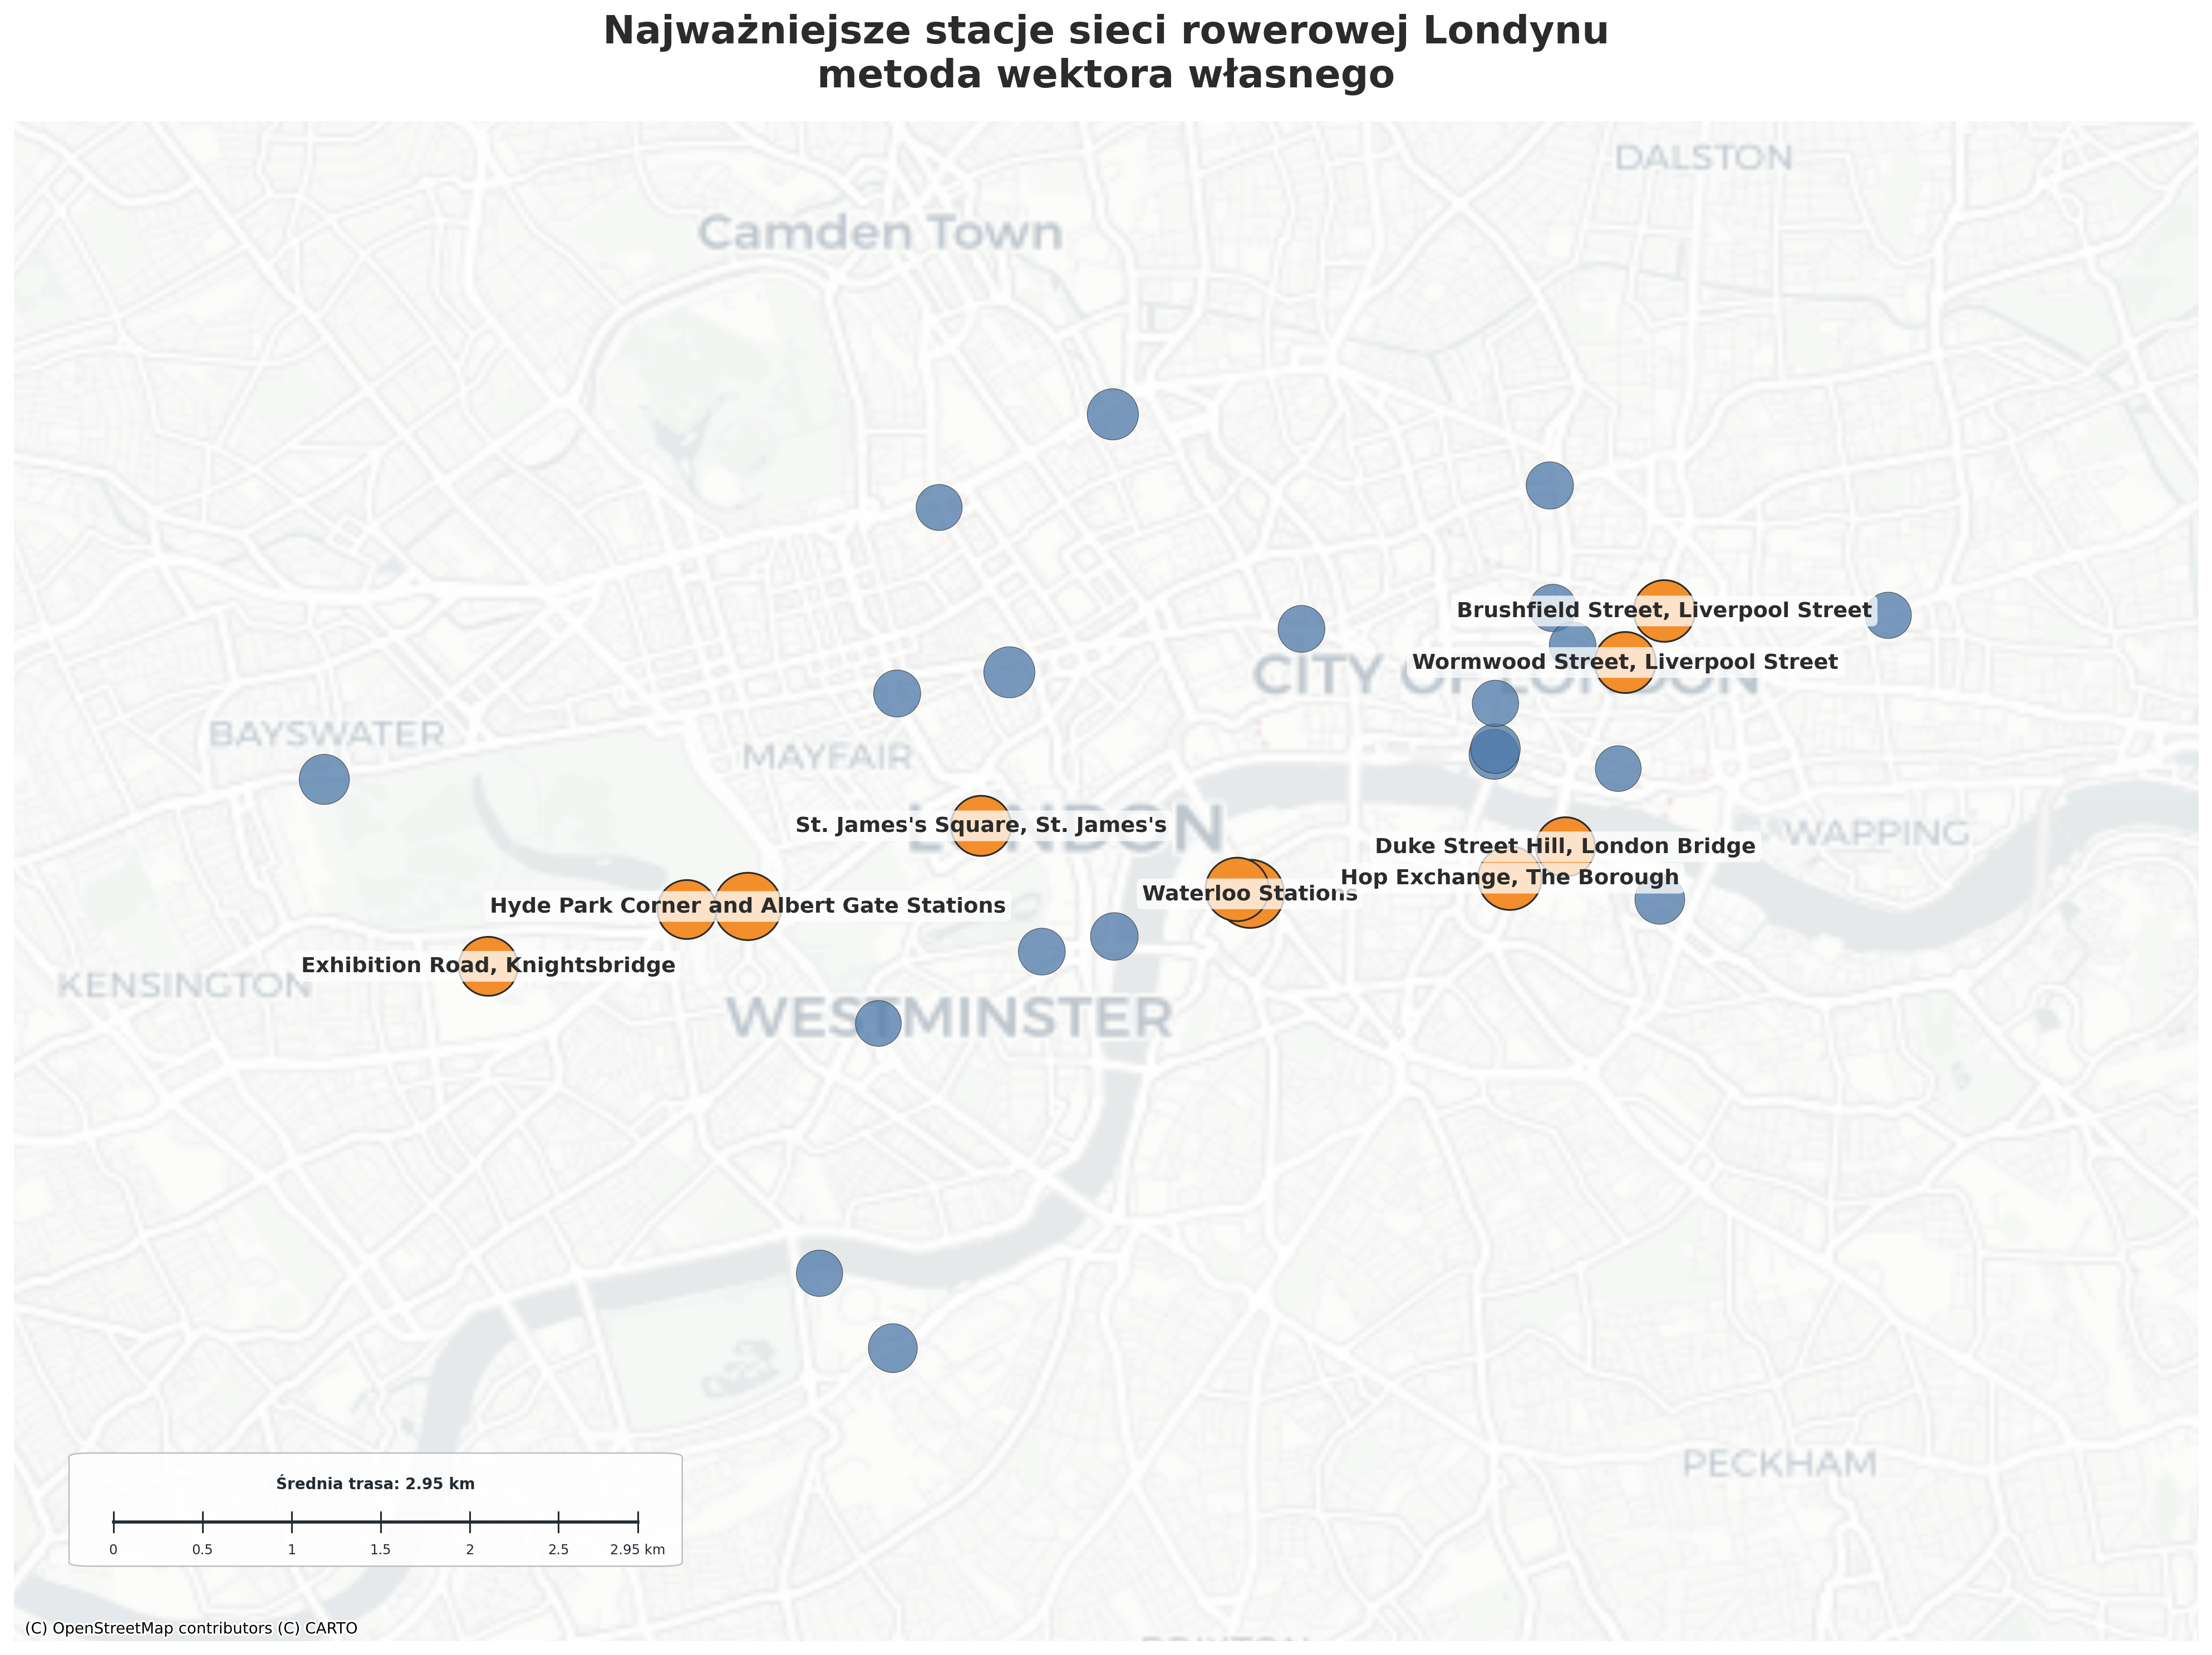

In [24]:
# ---------- Top 30 stations ----------

top_30_indices = sorted_indices[:30]

top_30_names = []

for idx in top_30_indices:

    station_id = index_to_station[idx]

    station_name = stations_df[
        stations_df["station_id"] == station_id
    ]["station_name"].values[0]

    top_30_names.append(station_name)


# ---------- Top 10 stations ----------

top_10_names = []

for idx in top_10_stations:

    station_id = index_to_station[idx]

    station_name = stations_df[
        stations_df["station_id"] == station_id
    ]["station_name"].values[0]

    top_10_names.append(station_name)


# ---------- Filtering strongest edges ----------

min_weight = 400

filtered_edges_df = edges_df[
    (edges_df["start_station_name"] != edges_df["end_station_name"]) &
    (edges_df["weight"] >= min_weight)
].copy()


# ---------- Building filtered graph ----------

filtered_graph = nx.from_pandas_edgelist(
    filtered_edges_df,
    source="start_station_name",
    target="end_station_name",
    edge_attr="weight",
    create_using=nx.DiGraph()
)


# ---------- GeoDataFrame ----------

stations_df["lat"] = stations_df["lat"].astype(float)
stations_df["lon"] = stations_df["lon"].astype(float)

geo_df = gpd.GeoDataFrame(
    stations_df,
    geometry=gpd.points_from_xy(
        stations_df["lon"],
        stations_df["lat"]
    ),
    crs="EPSG:4326"
)

geo_df = geo_df.to_crs(epsg=3857)


# ---------- Positions in EPSG:3857 ----------

positions_3857 = {}

for _, row in geo_df.iterrows():

    positions_3857[row["station_name"]] = (
        row.geometry.x,
        row.geometry.y
    )


# ---------- Stationary distribution dictionary ----------

stationary_dict = {}

for idx, probability in enumerate(stationary_distribution[0]):

    station_id = index_to_station[idx]

    station_name = stations_df[
        stations_df["station_id"] == station_id
    ]["station_name"].values[0]

    stationary_dict[station_name] = probability


# ---------- Node sizes proportional to stationary distribution ----------

top_30_node_sizes = [
    200 + 120000 * stationary_dict[node]
    for node in top_30_names
]

top_10_node_sizes = [
    300 + 150000 * stationary_dict[node]
    for node in top_10_names
]


# ---------- Labels ----------

labels_to_skip = [
    "Waterloo Station 1, Waterloo",
    "Albert Gate, Hyde Park"
]

labels = {}

for node in top_10_names:

    if node in labels_to_skip:
        continue

    elif node == "Waterloo Station 3, Waterloo":
        labels[node] = "Waterloo Stations"

    elif node == "Hyde Park Corner, Hyde Park":
        labels[node] = "Hyde Park Corner and Albert Gate Stations"

    else:
        labels[node] = node


# ---------- Plot style ----------

plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.titlesize"] = 20
plt.rcParams["axes.titleweight"] = "bold"


# ---------- Drawing ----------

fig, ax = plt.subplots(figsize=(16, 12), dpi=250)


# Top 30 stations

nx.draw_networkx_nodes(
    filtered_graph,
    positions_3857,
    nodelist=top_30_names,
    node_size=top_30_node_sizes,
    node_color="#4C78A8",
    alpha=0.75,
    edgecolors="#1f1f1f",
    linewidths=0.3,
    ax=ax
)


# Top 10 stations highlighted

nx.draw_networkx_nodes(
    filtered_graph,
    positions_3857,
    nodelist=top_10_names,
    node_size=top_10_node_sizes,
    node_color="#F28E2B",
    alpha=1.0,
    edgecolors="#2b2b2b",
    linewidths=0.9,
    ax=ax
)


# Labels for selected top 10 stations

text_items = nx.draw_networkx_labels(
    filtered_graph,
    positions_3857,
    labels=labels,
    font_size=11,
    font_weight="bold",
    font_color="#2b2b2b",
    font_family="DejaVu Sans",
    ax=ax
)

for _, text in text_items.items():

    text.set_bbox(
        dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.75,
            boxstyle="round,pad=0.25"
        )
    )


# ---------- Map extent ----------

x_values = [
    positions_3857[node][0]
    for node in top_30_names
]

y_values = [
    positions_3857[node][1]
    for node in top_30_names
]

ax.set_xlim(
    min(x_values) - padding,
    max(x_values) + padding
)

ax.set_ylim(
    min(y_values) - padding,
    max(y_values) + padding
)


# ---------- Basemap ----------

ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron
)

for image in ax.get_images():
    image.set_alpha(0.58)


# ---------- Average route scale bar ----------

add_average_route_scale_bar(
    ax,
    average_route_km
)


# ---------- Title ----------

ax.set_title(
    "Najważniejsze stacje sieci rowerowej Londynu\nmetoda wektora własnego",
    color="#2b2b2b",
    pad=18
)

ax.axis("off")
plt.tight_layout()
plt.show()

# ---------- Bilans liczby rowerów na stacji w ciągu dnia ----------

In [25]:
top_1_index = sorted_indices[0]
top_station_id = index_to_station[top_1_index]

top_station_name = stations_df[
    stations_df["station_id"] == top_station_id
]["station_name"].values[0]

print(f"Najważniejsza stacja według metody wektora własnego: {top_station_name}")

Najważniejsza stacja według metody wektora własnego: Waterloo Station 3, Waterloo
